In [2]:
# ============================================
# BANK CHURN ANALYTICS - Day 5
# Exploratory Data Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
df = pd.read_csv(r'D:\Python project\data\European_Bank_Cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(3)


# OVERALL CHURN RATE
total = len(df)
churned = df['Exited'].sum()
retained = total - churned
churn_rate = (churned / total * 100).round(2)

print("=" * 45)
print("OVERALL CHURN SUMMARY")
print("=" * 45)
print(f"Total Customers   : {total:,}")
print(f"Churned           : {churned:,}")
print(f"Retained          : {retained:,}")
print(f"Churn Rate        : {churn_rate}%")
print(f"\nIndustry Benchmark: 15%")
print(f"Our Dataset       : {churn_rate}%")
print(f"Difference        : +{(churn_rate - 15).round(2)}% above benchmark")

Dataset loaded successfully!
Shape: (10000, 19)
OVERALL CHURN SUMMARY
Total Customers   : 10,000
Churned           : 2,037
Retained          : 7,963
Churn Rate        : 20.37%

Industry Benchmark: 15%
Our Dataset       : 20.37%
Difference        : +5.37% above benchmark


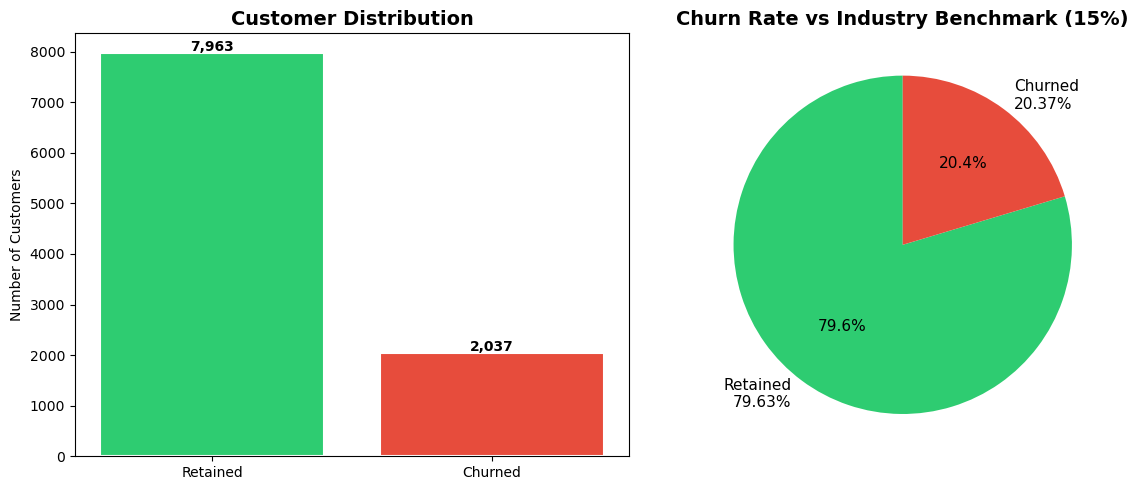

Chart saved!


In [3]:
# CHURN DISTRIBUTION CHART
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Count
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Retained', 'Churned'], [retained, churned], 
             color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Customer Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate([retained, churned]):
    axes[0].text(i, v + 50, str(f'{v:,}'), ha='center', fontweight='bold')

# Chart 2 - Pie
axes[1].pie([retained, churned], 
             labels=['Retained\n79.63%', 'Churned\n20.37%'],
             colors=colors, autopct='%1.1f%%',
             startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Churn Rate vs Industry Benchmark (15%)', 
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'D:\Python project\reports\01_churn_overview.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY GEOGRAPHY
           Churned  Total  ChurnRate
Geography                           
Germany        814   2509      32.44
Spain          413   2477      16.67
France         810   5014      16.15


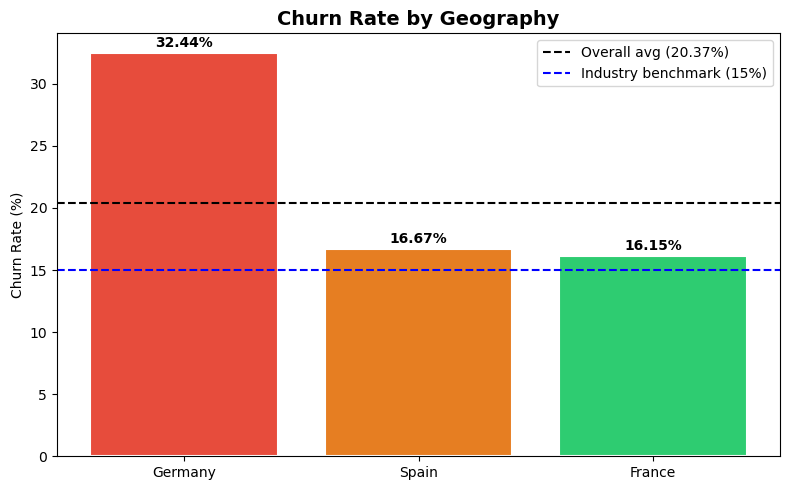

Chart saved!


In [4]:
# CHURN BY GEOGRAPHY
geo_churn = df.groupby('Geography')['Exited'].agg(['sum', 'count', 'mean'])
geo_churn.columns = ['Churned', 'Total', 'ChurnRate']
geo_churn['ChurnRate'] = (geo_churn['ChurnRate'] * 100).round(2)
geo_churn = geo_churn.sort_values('ChurnRate', ascending=False)

print("CHURN BY GEOGRAPHY")
print("=" * 45)
print(geo_churn)

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(geo_churn.index, geo_churn['ChurnRate'], 
               color=['#e74c3c', '#e67e22', '#2ecc71'],
               edgecolor='white', linewidth=1.5)
ax.axhline(y=20.37, color='black', linestyle='--', 
            linewidth=1.5, label='Overall avg (20.37%)')
ax.axhline(y=15, color='blue', linestyle='--', 
            linewidth=1.5, label='Industry benchmark (15%)')
for bar, rate in zip(bars, geo_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Geography', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\02_churn_by_geography.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY GENDER
        Churned  Total  ChurnRate
Gender                           
Female     1139   4543      25.07
Male        898   5457      16.46


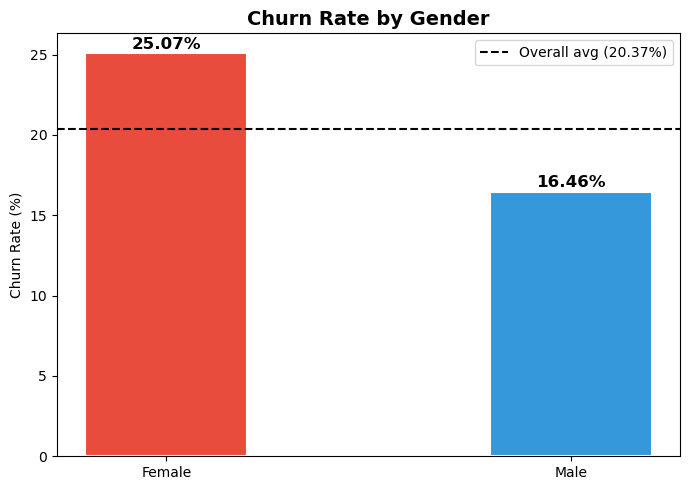

Chart saved!


In [5]:
# CHURN BY GENDER
gender_churn = df.groupby('Gender')['Exited'].agg(['sum','count','mean'])
gender_churn.columns = ['Churned', 'Total', 'ChurnRate']
gender_churn['ChurnRate'] = (gender_churn['ChurnRate'] * 100).round(2)

print("CHURN BY GENDER")
print("=" * 45)
print(gender_churn)

# Chart
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gender_churn.index, gender_churn['ChurnRate'],
               color=['#e74c3c', '#3498db'],
               edgecolor='white', linewidth=1.5, width=0.4)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, gender_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\03_churn_by_gender.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY AGE GROUP
          Churned  Total  ChurnRate
AgeGroup                           
30-45         932   5921      15.74
46-60         842   1647      51.12
60+           115    464      24.78
<30           148   1968       7.52


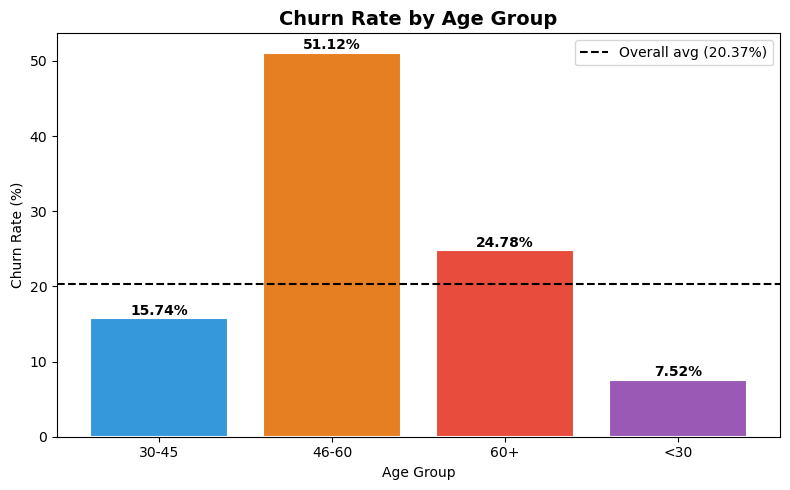

Chart saved!


In [6]:
# CHURN BY AGE GROUP
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].agg(['sum','count','mean'])
age_churn.columns = ['Churned', 'Total', 'ChurnRate']
age_churn['ChurnRate'] = (age_churn['ChurnRate'] * 100).round(2)

print("CHURN BY AGE GROUP")
print("=" * 45)
print(age_churn)

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_churn.index, age_churn['ChurnRate'],
               color=['#3498db','#e67e22','#e74c3c','#9b59b6'],
               edgecolor='white', linewidth=1.5)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, age_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Group')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\04_churn_by_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY ACTIVE MEMBER STATUS
          Churned  Total  ChurnRate
Inactive     1302   4849      26.85
Active        735   5151      14.27


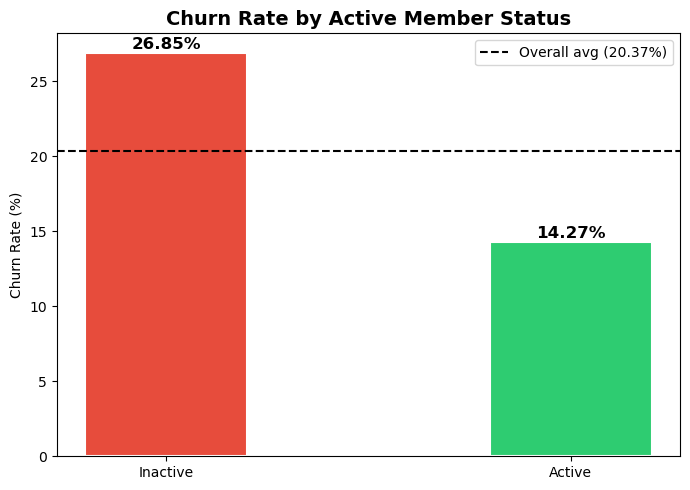

Chart saved!


In [7]:
# CHURN BY ACTIVE MEMBER STATUS
active_churn = df.groupby('IsActiveMember')['Exited'].agg(['sum','count','mean'])
active_churn.columns = ['Churned', 'Total', 'ChurnRate']
active_churn['ChurnRate'] = (active_churn['ChurnRate'] * 100).round(2)
active_churn.index = ['Inactive', 'Active']

print("CHURN BY ACTIVE MEMBER STATUS")
print("=" * 45)
print(active_churn)

# Chart
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(active_churn.index, active_churn['ChurnRate'],
               color=['#e74c3c', '#2ecc71'],
               edgecolor='white', linewidth=1.5, width=0.4)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, active_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Active Member Status', 
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\05_churn_by_active_status.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
# CHURN BY CREDIT CARD OWNERSHIP
cc_churn = df.groupby('HasCrCard')['Exited'].agg(['sum','count','mean'])
cc_churn.columns = ['Churned', 'Total', 'ChurnRate']
cc_churn['ChurnRate'] = (cc_churn['ChurnRate'] * 100).round(2)
cc_churn.index = ['No Card', 'Has Card']

print("CHURN BY CREDIT CARD OWNERSHIP")
print("=" * 45)
print(cc_churn)

CHURN BY CREDIT CARD OWNERSHIP
          Churned  Total  ChurnRate
No Card       613   2945      20.81
Has Card     1424   7055      20.18


In [9]:
# DAY 5 FINDINGS SUMMARY
print("=" * 55)
print("DAY 5 — KEY FINDINGS SUMMARY")
print("=" * 55)
print("""
1. Overall churn rate    : 20.37% (+5.37% above benchmark)

2. Geography churn:
   Germany               : 32.44% ← H2 CONFIRMED
   Spain                 : 16.67%
   France                : 16.15%

3. Gender churn:
   Female                : 25.07% ← H5 CONFIRMED
   Male                  : 16.46%

4. Age group churn:
   46-60                 : 51.12% ← MOST ALARMING FINDING
   60+                   : 24.78%
   30-45                 : 15.74%
   <30                   : 7.52%  ← H1 REJECTED

5. Active Member churn:
   Inactive              : 26.85% ← H4 PARTIALLY CONFIRMED
   Active                : 14.27%

6. Credit Card churn:
   No Card               : 20.81%
   Has Card              : 20.18% ← NO IMPACT ON CHURN
""")

DAY 5 — KEY FINDINGS SUMMARY

1. Overall churn rate    : 20.37% (+5.37% above benchmark)

2. Geography churn:
   Germany               : 32.44% ← H2 CONFIRMED
   Spain                 : 16.67%
   France                : 16.15%

3. Gender churn:
   Female                : 25.07% ← H5 CONFIRMED
   Male                  : 16.46%

4. Age group churn:
   46-60                 : 51.12% ← MOST ALARMING FINDING
   60+                   : 24.78%
   30-45                 : 15.74%
   <30                   : 7.52%  ← H1 REJECTED

5. Active Member churn:
   Inactive              : 26.85% ← H4 PARTIALLY CONFIRMED
   Active                : 14.27%

6. Credit Card churn:
   No Card               : 20.81%
   Has Card              : 20.18% ← NO IMPACT ON CHURN



## Day 6 — Financial Profile Analysis

CHURN BY NUMBER OF PRODUCTS
               Churned  Total  ChurnRate
NumOfProducts                           
1                 1409   5084      27.71
2                  348   4590       7.58
3                  220    266      82.71
4                   60     60     100.00


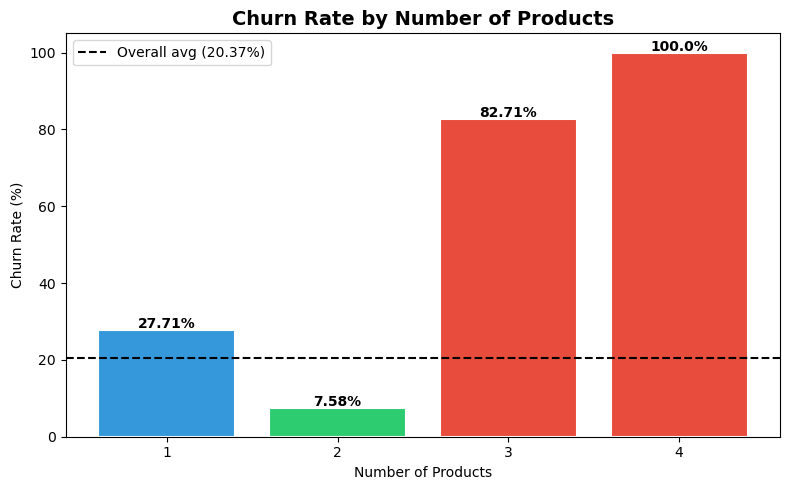

Chart saved!


In [10]:
# CHURN BY NUMBER OF PRODUCTS
prod_churn = df.groupby('NumOfProducts')['Exited'].agg(['sum','count','mean'])
prod_churn.columns = ['Churned', 'Total', 'ChurnRate']
prod_churn['ChurnRate'] = (prod_churn['ChurnRate'] * 100).round(2)

print("CHURN BY NUMBER OF PRODUCTS")
print("=" * 45)
print(prod_churn)

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(prod_churn.index.astype(str), prod_churn['ChurnRate'],
               color=['#3498db','#2ecc71','#e74c3c','#e74c3c'],
               edgecolor='white', linewidth=1.5)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, prod_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Number of Products', 
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Products')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\06_churn_by_products.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY BALANCE SEGMENT
                Churned  Total  ChurnRate
BalanceSegment                           
High                653   2731      23.91
Low                  26     75      34.67
Medium              858   3577      23.99
Zero                500   3617      13.82


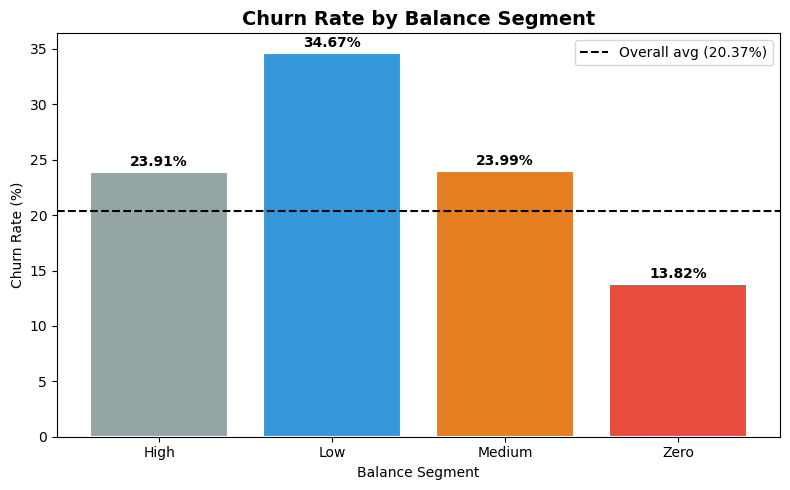

Chart saved!


In [11]:
# CHURN BY BALANCE SEGMENT
bal_churn = df.groupby('BalanceSegment', observed=True)['Exited'].agg(['sum','count','mean'])
bal_churn.columns = ['Churned', 'Total', 'ChurnRate']
bal_churn['ChurnRate'] = (bal_churn['ChurnRate'] * 100).round(2)

print("CHURN BY BALANCE SEGMENT")
print("=" * 45)
print(bal_churn)

# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bal_churn.index, bal_churn['ChurnRate'],
               color=['#95a5a6','#3498db','#e67e22','#e74c3c'],
               edgecolor='white', linewidth=1.5)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, bal_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Balance Segment',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Balance Segment')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\07_churn_by_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY CREDIT SCORE BAND
            Churned  Total  ChurnRate
CreditBand                           
High            486   2408      20.18
Low             530   2393      22.15
Medium         1021   5199      19.64


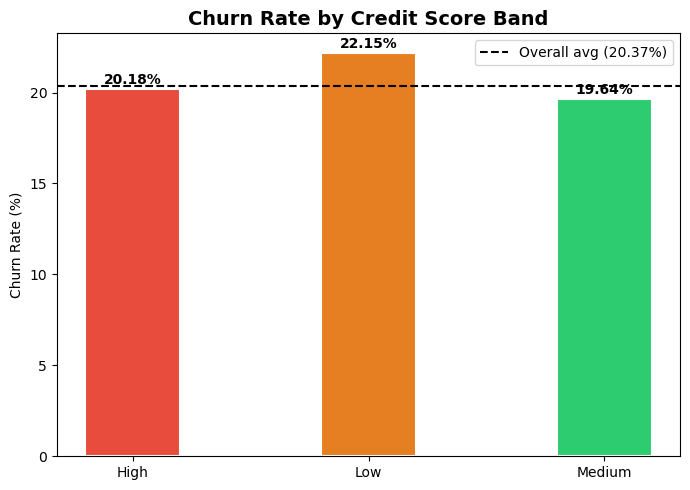

Chart saved!


In [12]:
# CHURN BY CREDIT SCORE BAND
credit_churn = df.groupby('CreditBand', observed=True)['Exited'].agg(['sum','count','mean'])
credit_churn.columns = ['Churned', 'Total', 'ChurnRate']
credit_churn['ChurnRate'] = (credit_churn['ChurnRate'] * 100).round(2)

print("CHURN BY CREDIT SCORE BAND")
print("=" * 45)
print(credit_churn)

# Chart
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(credit_churn.index, credit_churn['ChurnRate'],
               color=['#e74c3c','#e67e22','#2ecc71'],
               edgecolor='white', linewidth=1.5, width=0.4)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, credit_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Credit Score Band',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\08_churn_by_creditscore.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY TENURE GROUP
             Churned  Total  ChurnRate
TenureGroup                           
Long             688   3527      19.51
Mid              821   3977      20.64
New              528   2496      21.15


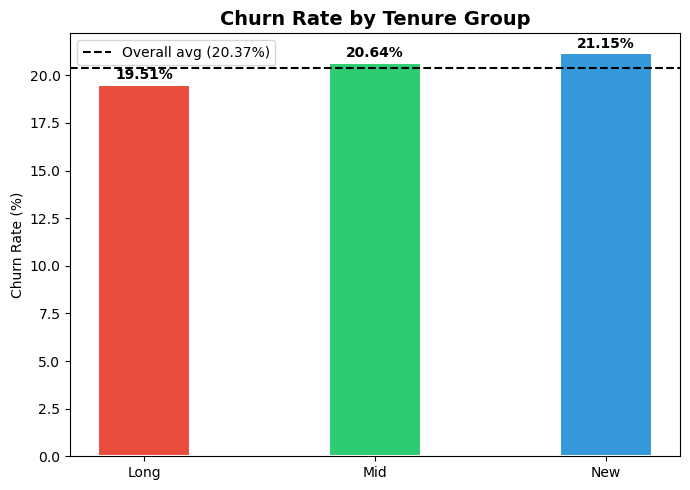

Chart saved!


In [13]:
# CHURN BY TENURE GROUP
tenure_churn = df.groupby('TenureGroup', observed=True)['Exited'].agg(['sum','count','mean'])
tenure_churn.columns = ['Churned', 'Total', 'ChurnRate']
tenure_churn['ChurnRate'] = (tenure_churn['ChurnRate'] * 100).round(2)

print("CHURN BY TENURE GROUP")
print("=" * 45)
print(tenure_churn)

# Chart
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(tenure_churn.index, tenure_churn['ChurnRate'],
               color=['#e74c3c','#2ecc71','#3498db'],
               edgecolor='white', linewidth=1.5, width=0.4)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, tenure_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Tenure Group',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\09_churn_by_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN BY CLV SEGMENT
             Churned  Total  ChurnRate  Avg_Balance_Churned
CLV_Segment                                                
High             603   2500      24.12            117576.72
Low              346   2500      13.84              2062.83
Medium           483   2500      19.32             63011.32
Premium          605   2500      24.20            138084.51


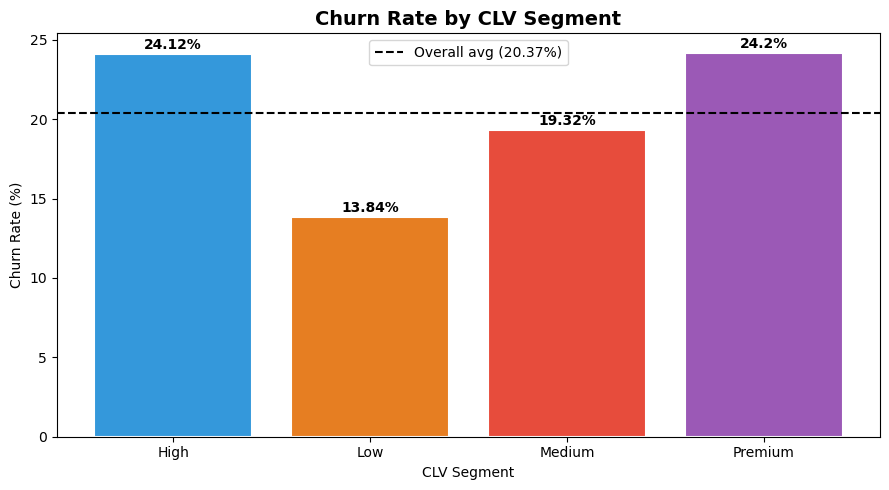

Chart saved!


In [15]:
# CHURN BY CLV SEGMENT
clv_churn = df.groupby('CLV_Segment', observed=True)['Exited'].agg(['sum','count','mean'])
clv_churn.columns = ['Churned', 'Total', 'ChurnRate']
clv_churn['ChurnRate'] = (clv_churn['ChurnRate'] * 100).round(2)

# Add average balance of churned customers per segment
clv_balance = df[df['Exited']==1].groupby('CLV_Segment', 
               observed=True)['Balance'].mean().round(2)
clv_churn['Avg_Balance_Churned'] = clv_balance

print("CHURN BY CLV SEGMENT")
print("=" * 50)
print(clv_churn)

# Chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(clv_churn.index, clv_churn['ChurnRate'],
               color=['#3498db','#e67e22','#e74c3c','#9b59b6'],
               edgecolor='white', linewidth=1.5)
ax.axhline(y=20.37, color='black', linestyle='--',
            linewidth=1.5, label='Overall avg (20.37%)')
for bar, rate in zip(bars, clv_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by CLV Segment',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('CLV Segment')
ax.legend()
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\10_churn_by_clv.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [16]:
# REVENUE AT RISK BY CLV SEGMENT
revenue_risk = df[df['Exited']==1].groupby('CLV_Segment', 
                observed=True)['Balance'].agg(['sum','mean','count'])
revenue_risk.columns = ['Total_Balance_Lost', 'Avg_Balance', 'Customers_Lost']
revenue_risk = revenue_risk.sort_values('Total_Balance_Lost', ascending=False)

print("REVENUE AT RISK BY CLV SEGMENT")
print("=" * 55)
print(revenue_risk)

total_revenue_at_risk = df[df['Exited']==1]['Balance'].sum()
print(f"\nTOTAL REVENUE AT RISK (all churned customers): €{total_revenue_at_risk:,.2f}")

REVENUE AT RISK BY CLV SEGMENT
             Total_Balance_Lost    Avg_Balance  Customers_Lost
CLV_Segment                                                   
Premium             83541128.12  138084.509289             605
High                70898760.31  117576.716932             603
Medium              30434466.59   63011.317992             483
Low                   713739.61    2062.831243             346

TOTAL REVENUE AT RISK (all churned customers): €185,588,094.63


In [17]:
# DAY 6 FINDINGS SUMMARY
print("=" * 55)
print("DAY 6 — KEY FINDINGS SUMMARY")
print("=" * 55)
print("""
1. Products churn (U-shaped):
   1 product   : 27.71%
   2 products  : 7.58%  ← sweet spot
   3 products  : 82.71% ← alarming
   4 products  : 100%   ← total loss

2. Balance segment churn:
   Zero        : 13.82% (dormant savers — H4 support)
   High        : 23.91% (revenue risk — H3 support)

3. Credit Score: No meaningful impact (~20% across all bands)

4. Tenure Group: No meaningful impact (~19-21% across all)

5. CLV Segment — MOST CRITICAL FINDING:
   Premium     : 24.20% churn, €83.5M lost
   High        : 24.12% churn, €70.9M lost
   Medium      : 19.32% churn, €30.4M lost
   Low         : 13.84% churn, €0.7M lost
   
   TOTAL REVENUE AT RISK: €185,588,094.63
   83% concentrated in High + Premium segments
""")

DAY 6 — KEY FINDINGS SUMMARY

1. Products churn (U-shaped):
   1 product   : 27.71%
   2 products  : 7.58%  ← sweet spot
   3 products  : 82.71% ← alarming
   4 products  : 100%   ← total loss

2. Balance segment churn:
   Zero        : 13.82% (dormant savers — H4 support)
   High        : 23.91% (revenue risk — H3 support)

3. Credit Score: No meaningful impact (~20% across all bands)

4. Tenure Group: No meaningful impact (~19-21% across all)

5. CLV Segment — MOST CRITICAL FINDING:
   Premium     : 24.20% churn, €83.5M lost
   High        : 24.12% churn, €70.9M lost
   Medium      : 19.32% churn, €30.4M lost
   Low         : 13.84% churn, €0.7M lost

   TOTAL REVENUE AT RISK: €185,588,094.63
   83% concentrated in High + Premium segments



## Day 7 — Multivariate Analysis

CHURN RATE: GEOGRAPHY x GENDER
Gender     Female   Male
Geography               
France      20.34  12.71
Germany     37.55  27.81
Spain       21.21  13.11


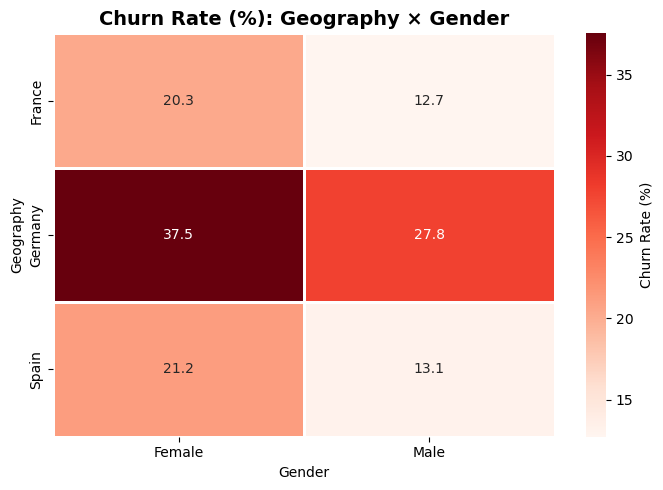

Chart saved!


In [18]:
# GEOGRAPHY x GENDER HEATMAP
pivot1 = df.pivot_table(values='Exited', index='Geography', 
                         columns='Gender', aggfunc='mean') * 100
pivot1 = pivot1.round(2)

print("CHURN RATE: GEOGRAPHY x GENDER")
print("=" * 45)
print(pivot1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Churn Rate (%)'}, 
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Churn Rate (%): Geography × Gender',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\11_heatmap_geo_gender.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN RATE: GEOGRAPHY x AGE GROUP
AgeGroup   30-45  46-60    60+    <30
Geography                            
France     12.35  45.79  19.91   4.91
Germany    26.09  67.33  38.94  12.36
Spain      12.53  40.66  20.83   8.60


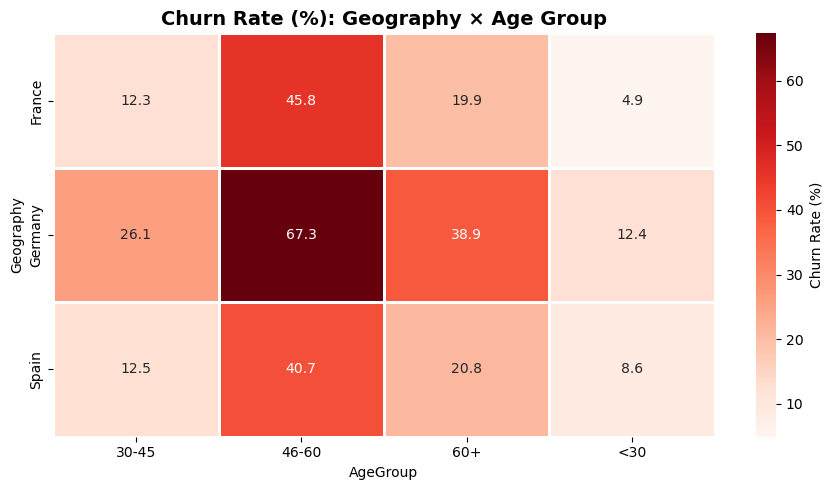

Chart saved!


In [19]:
# GEOGRAPHY x AGE GROUP HEATMAP
pivot2 = df.pivot_table(values='Exited', index='Geography',
                         columns='AgeGroup', aggfunc='mean', 
                         observed=True) * 100
pivot2 = pivot2.round(2)

print("CHURN RATE: GEOGRAPHY x AGE GROUP")
print("=" * 50)
print(pivot2)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Churn Rate (%)'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Churn Rate (%): Geography × Age Group',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\12_heatmap_geo_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CHURN RATE: AGE GROUP x BALANCE SEGMENT
BalanceSegment   High    Low  Medium   Zero
AgeGroup                                   
30-45           18.99  28.89   18.23  10.58
46-60           54.70  72.73   56.20  41.25
60+             29.13  50.00   31.10  14.37
<30             10.96  15.38    8.72   4.03


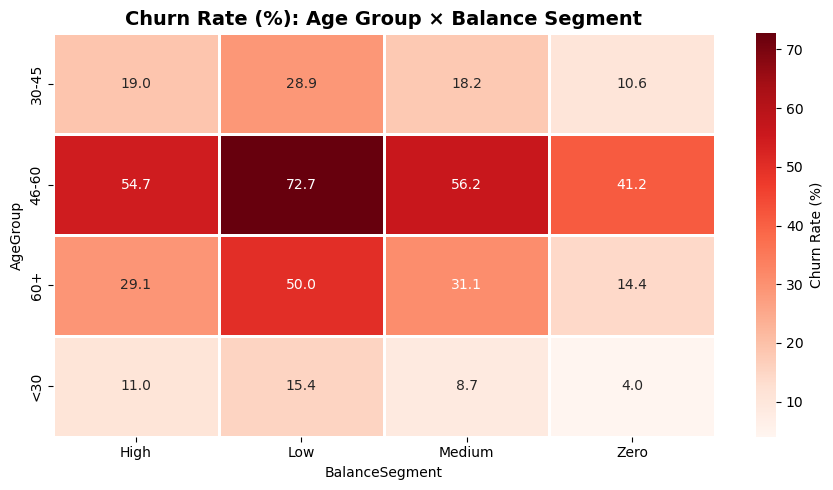

Chart saved!


In [20]:
# AGE GROUP x BALANCE SEGMENT HEATMAP
pivot3 = df.pivot_table(values='Exited', index='AgeGroup',
                         columns='BalanceSegment', aggfunc='mean',
                         observed=True) * 100
pivot3 = pivot3.round(2)

print("CHURN RATE: AGE GROUP x BALANCE SEGMENT")
print("=" * 50)
print(pivot3)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Churn Rate (%)'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Churn Rate (%): Age Group × Balance Segment',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\13_heatmap_age_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

CORRELATION WITH EXITED (sorted)
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


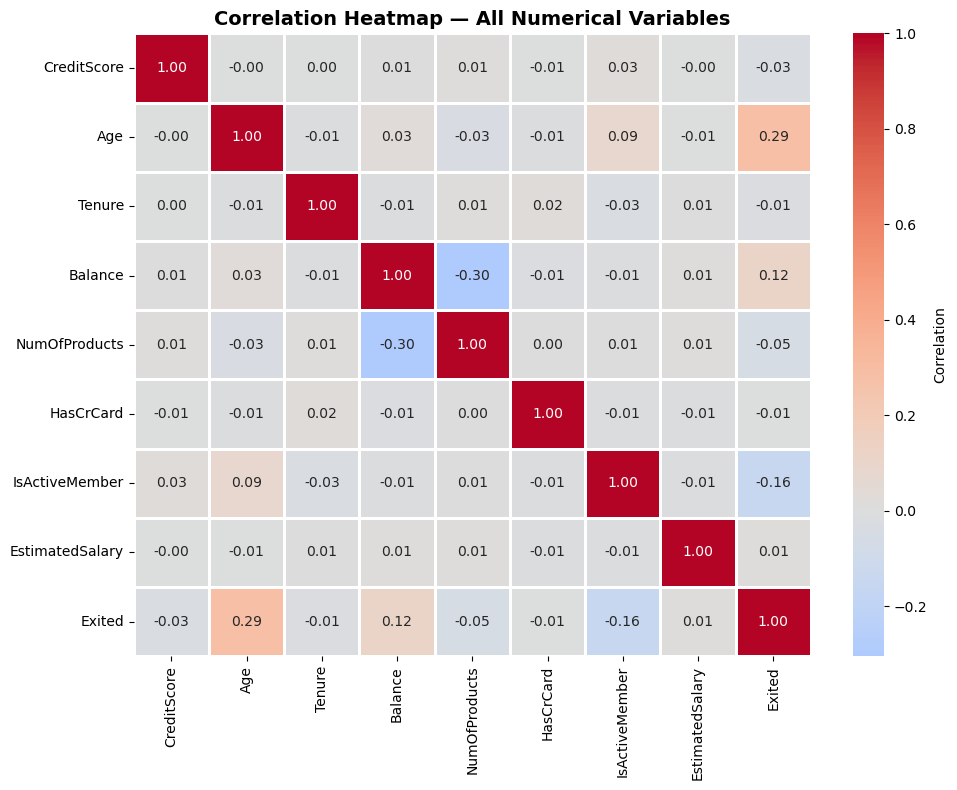

Chart saved!


In [21]:
# CORRELATION HEATMAP
numerical_for_corr = ['CreditScore', 'Age', 'Tenure', 'Balance',
                       'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                       'EstimatedSalary', 'Exited']

corr_matrix = df[numerical_for_corr].corr()

print("CORRELATION WITH EXITED (sorted)")
print("=" * 45)
print(corr_matrix['Exited'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Heatmap — All Numerical Variables',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\14_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

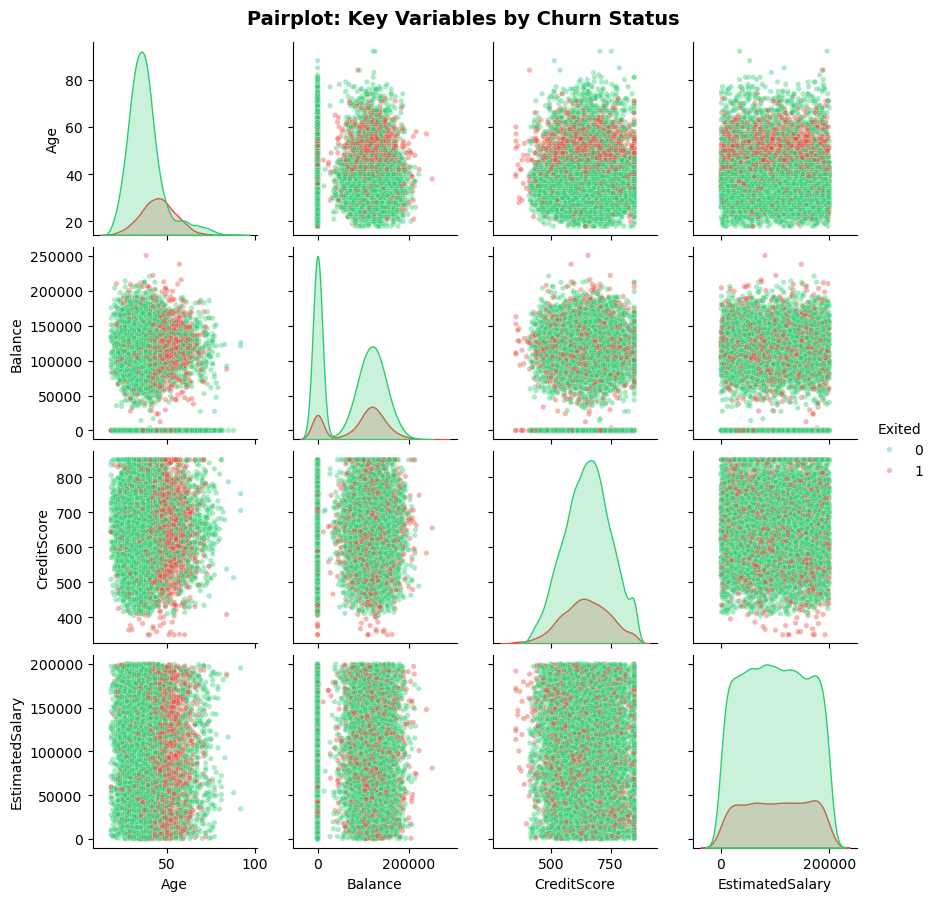

Chart saved!


In [22]:
# PAIRPLOT colored by Exited
plot_cols = ['Age', 'Balance', 'CreditScore', 
             'EstimatedSalary', 'Exited']

g = sns.pairplot(df[plot_cols], hue='Exited', 
                  palette=['#2ecc71', '#e74c3c'],
                  diag_kind='kde', height=2.2,
                  plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Pairplot: Key Variables by Churn Status', 
                y=1.02, fontsize=14, fontweight='bold')
g._legend.set_title('Exited')

plt.savefig(r'D:\Python project\reports\15_pairplot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [23]:
print("=" * 55)
print("DAY 7 — MULTIVARIATE ANALYSIS SUMMARY")
print("=" * 55)
print("""
1. Geography × Gender: Germany+Female = 37.55% (worst combo)
2. Geography × Age: Germany+46-60 = 67.33% (most extreme)
3. Age × Balance: 46-60+Low Balance = 72.73% (highest cell)
4. Correlation: Age (+0.29), IsActiveMember (-0.16), 
   Balance (+0.12) are top linear predictors
5. NumOfProducts correlation misleadingly low (-0.05) due 
   to non-linear U-shaped relationship — methodology note
6. Balance distribution is bimodal — two customer populations
7. CreditScore & EstimatedSalary confirmed as weak predictors
""")

DAY 7 — MULTIVARIATE ANALYSIS SUMMARY

1. Geography × Gender: Germany+Female = 37.55% (worst combo)
2. Geography × Age: Germany+46-60 = 67.33% (most extreme)
3. Age × Balance: 46-60+Low Balance = 72.73% (highest cell)
4. Correlation: Age (+0.29), IsActiveMember (-0.16), 
   Balance (+0.12) are top linear predictors
5. NumOfProducts correlation misleadingly low (-0.05) due 
   to non-linear U-shaped relationship — methodology note
6. Balance distribution is bimodal — two customer populations
7. CreditScore & EstimatedSalary confirmed as weak predictors



In [24]:
import os
print("Current working directory:", os.getcwd())
print("\nNotebook absolute path likely at:")
print(os.path.join(os.getcwd(), '02_exploratory_data_analysis.ipynb'))

Current working directory: C:\Users\Lenovo

Notebook absolute path likely at:
C:\Users\Lenovo\02_exploratory_data_analysis.ipynb


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import shap
import lifelines
import streamlit
print("All libraries loaded successfully in venv!")

All libraries loaded successfully in venv!


## Day 8 — Survival Analysis (Kaplan-Meier)

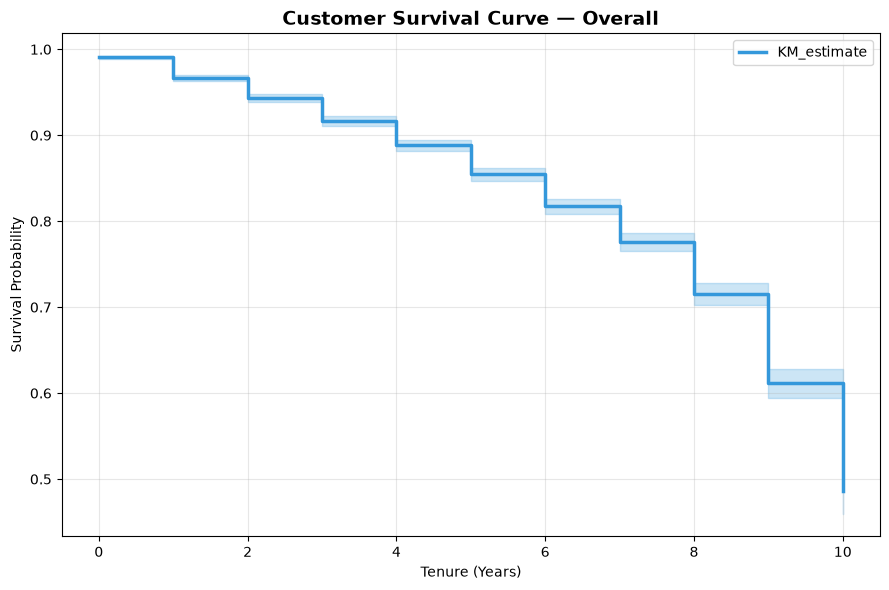

Chart saved!

Median survival time: 10.0


In [4]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df['Tenure'], event_observed=df['Exited'])

fig, ax = plt.subplots(figsize=(9, 6))
kmf.plot_survival_function(ax=ax, color='#3498db', linewidth=2.5)
ax.set_title('Customer Survival Curve — Overall', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\16_survival_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

print(f"\nMedian survival time: {kmf.median_survival_time_}")

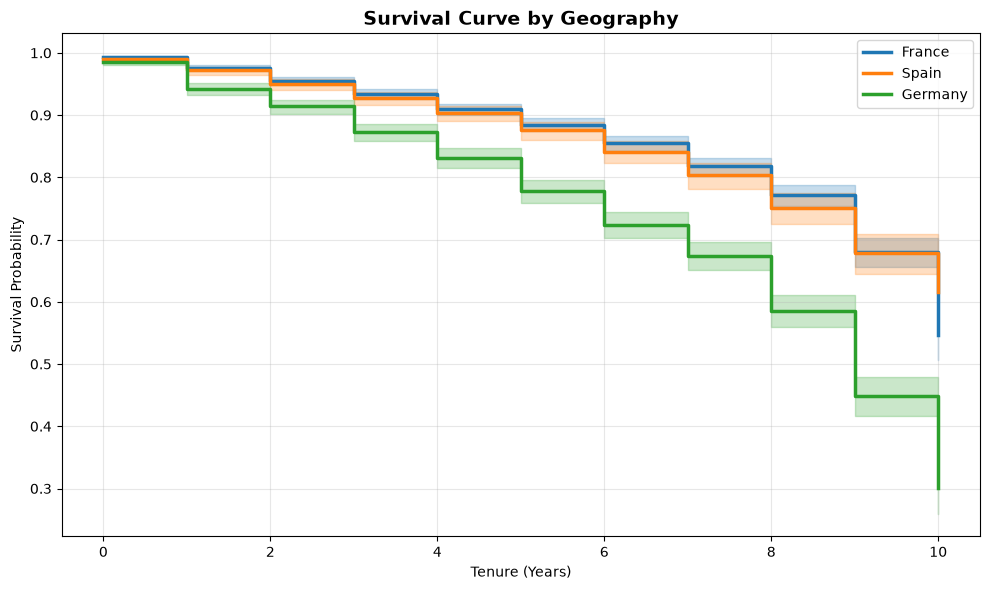

Chart saved!


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for country in df['Geography'].unique():
    mask = df['Geography'] == country
    kmf_country = KaplanMeierFitter()
    kmf_country.fit(df[mask]['Tenure'], 
                     event_observed=df[mask]['Exited'],
                     label=country)
    kmf_country.plot_survival_function(ax=ax, linewidth=2.5)

ax.set_title('Survival Curve by Geography', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\17_survival_by_geography.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

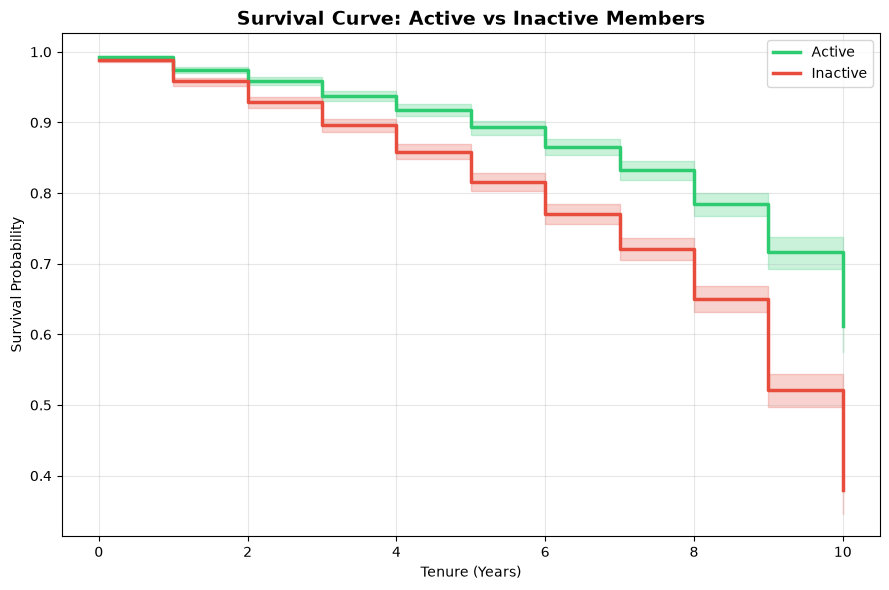

Chart saved!


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

for status, label, color in [(1, 'Active', '#2ecc71'), 
                               (0, 'Inactive', '#e74c3c')]:
    mask = df['IsActiveMember'] == status
    kmf_status = KaplanMeierFitter()
    kmf_status.fit(df[mask]['Tenure'],
                    event_observed=df[mask]['Exited'],
                    label=label)
    kmf_status.plot_survival_function(ax=ax, linewidth=2.5, color=color)

ax.set_title('Survival Curve: Active vs Inactive Members',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\18_survival_active_status.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

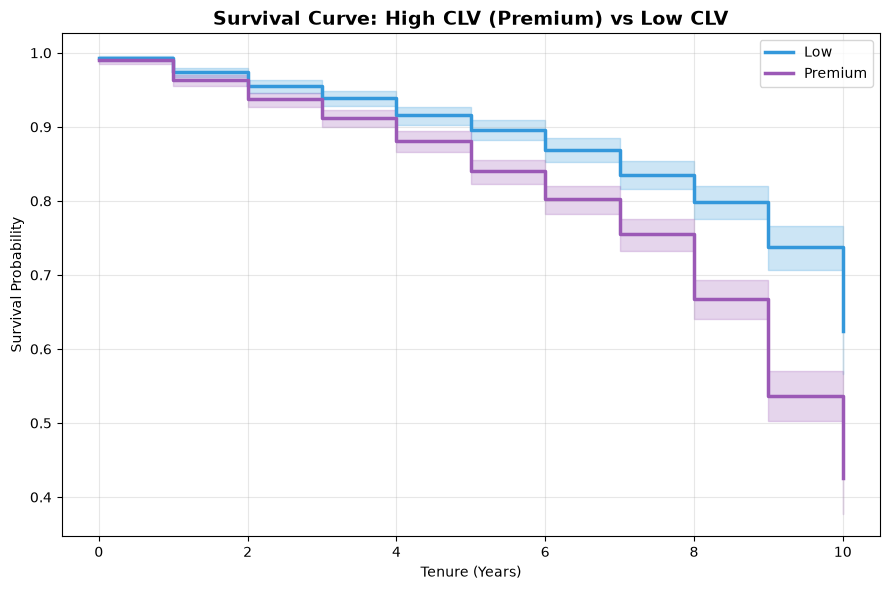

Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

clv_subset = df[df['CLV_Segment'].isin(['Low', 'Premium'])]
colors = {'Low': '#3498db', 'Premium': '#9b59b6'}

for segment in ['Low', 'Premium']:
    mask = clv_subset['CLV_Segment'] == segment
    kmf_clv = KaplanMeierFitter()
    kmf_clv.fit(clv_subset[mask]['Tenure'],
                event_observed=clv_subset[mask]['Exited'],
                label=segment)
    kmf_clv.plot_survival_function(ax=ax, linewidth=2.5, 
                                     color=colors[segment])

ax.set_title('Survival Curve: High CLV (Premium) vs Low CLV',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\19_survival_clv.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [7]:
print("=" * 55)
print("DAY 8 — SURVIVAL ANALYSIS SUMMARY")
print("=" * 55)
print("""
1. Overall: Steady, gradual decline — no single shock 
   point. Service quality erosion, not onboarding failure.

2. Geography: Germany separates from France/Spain by 
   year 2-3, gap widens continuously. 35% vs 70% 
   survival at year 10. Structural, early-onset problem.

3. Active vs Inactive: Consistent ~25-28pt gap throughout. 
   Active 70% vs Inactive 42% survival at year 10.
   Confirms engagement as durable protective factor.
""")

DAY 8 — SURVIVAL ANALYSIS SUMMARY

1. Overall: Steady, gradual decline — no single shock 
   point. Service quality erosion, not onboarding failure.

2. Geography: Germany separates from France/Spain by 
   year 2-3, gap widens continuously. 35% vs 70% 
   survival at year 10. Structural, early-onset problem.

3. Active vs Inactive: Consistent ~25-28pt gap throughout. 
   Active 70% vs Inactive 42% survival at year 10.
   Confirms engagement as durable protective factor.



## Day 9 — Statistical Hypothesis Testing

In [3]:
from scipy.stats import chi2_contingency, ttest_ind

print("CHI-SQUARE TESTS — CATEGORICAL vs CHURN")
print("=" * 55)

categorical_vars = ['Geography', 'Gender', 'HasCrCard', 
                    'IsActiveMember', 'NumOfProducts']

for var in categorical_vars:
    contingency = pd.crosstab(df[var], df['Exited'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    significance = "✅ SIGNIFICANT" if p < 0.05 else "❌ NOT SIGNIFICANT"
    print(f"{var:<20} | p-value: {p:.6f} | {significance}")

CHI-SQUARE TESTS — CATEGORICAL vs CHURN
Geography            | p-value: 0.000000 | ✅ SIGNIFICANT
Gender               | p-value: 0.000000 | ✅ SIGNIFICANT
HasCrCard            | p-value: 0.492372 | ❌ NOT SIGNIFICANT
IsActiveMember       | p-value: 0.000000 | ✅ SIGNIFICANT
NumOfProducts        | p-value: 0.000000 | ✅ SIGNIFICANT


In [4]:
print("\nT-TESTS — NUMERICAL VARIABLES vs CHURN")
print("=" * 55)

churned = df[df['Exited'] == 1]
retained = df[df['Exited'] == 0]

numerical_vars = ['Age', 'Balance', 'CreditScore', 
                  'EstimatedSalary', 'Tenure']

for var in numerical_vars:
    t_stat, p = ttest_ind(churned[var], retained[var])
    significance = "✅ SIGNIFICANT" if p < 0.05 else "❌ NOT SIGNIFICANT"
    churned_mean = churned[var].mean().round(2)
    retained_mean = retained[var].mean().round(2)
    print(f"{var:<20} | p-value: {p:.6f} | {significance}")
    print(f"{'':20}   Churned mean: {churned_mean} | "
          f"Retained mean: {retained_mean}")
    print()


T-TESTS — NUMERICAL VARIABLES vs CHURN
Age                  | p-value: 0.000000 | ✅ SIGNIFICANT
                       Churned mean: 44.84 | Retained mean: 37.41

Balance              | p-value: 0.000000 | ✅ SIGNIFICANT
                       Churned mean: 91108.54 | Retained mean: 72745.3

CreditScore          | p-value: 0.006738 | ✅ SIGNIFICANT
                       Churned mean: 645.35 | Retained mean: 651.85

EstimatedSalary      | p-value: 0.226440 | ❌ NOT SIGNIFICANT
                       Churned mean: 101465.68 | Retained mean: 99738.39

Tenure               | p-value: 0.161527 | ❌ NOT SIGNIFICANT
                       Churned mean: 4.93 | Retained mean: 5.03



In [5]:
from scipy.stats import pointbiserialr

print("POINT-BISERIAL CORRELATION WITH EXITED")
print("=" * 55)

numerical_cols = ['Age', 'Balance', 'CreditScore', 
                  'EstimatedSalary', 'Tenure', 
                  'NumOfProducts', 'HasCrCard', 
                  'IsActiveMember', 'CLV_Score',
                  'EngagementScore', 'Balance_Salary_Ratio']

results = []
for col in numerical_cols:
    corr, p = pointbiserialr(df['Exited'], df[col])
    results.append({'Variable': col, 
                    'Correlation': round(corr, 4), 
                    'P_Value': round(p, 6)})

corr_df = pd.DataFrame(results)
corr_df = corr_df.reindex(
    corr_df['Correlation'].abs().sort_values(ascending=False).index
)
corr_df['Significance'] = corr_df['P_Value'].apply(
    lambda p: '✅' if p < 0.05 else '❌'
)

print(corr_df.to_string(index=False))

POINT-BISERIAL CORRELATION WITH EXITED
            Variable  Correlation  P_Value Significance
                 Age       0.2853 0.000000            ✅
      IsActiveMember      -0.1561 0.000000            ✅
     EngagementScore      -0.1379 0.000000            ✅
             Balance       0.1185 0.000000            ✅
           CLV_Score       0.1088 0.000000            ✅
       NumOfProducts      -0.0478 0.000002            ✅
         CreditScore      -0.0271 0.006738            ✅
Balance_Salary_Ratio       0.0256 0.010591            ✅
              Tenure      -0.0140 0.161527            ❌
     EstimatedSalary       0.0121 0.226440            ❌
           HasCrCard      -0.0071 0.475415            ❌
